In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
# 1. Import Libraries
# ==============================
import pandas as pd
import numpy as np
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)
from keras.models import Model
from keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from keras.layers import Input, Dense, Flatten, MultiHeadAttention, Dropout
import tensorflow as tf

In [25]:
# ==============================
# 2. Load Dataset
# ==============================
df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/Research/Diabetes/diabetes_012_health_indicators_BRFSS2015.csv')

print("Dataset Shape:", df.shape)

Dataset Shape: (253680, 22)


In [26]:
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [27]:
# ==============================
# 3. Features & Target
# ==============================
X = df.drop('Diabetes_012', axis=1)
y = df['Diabetes_012']


# ==============================
# 4. Train-Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3
)

In [28]:
# ==============================
# 5. Feature Scaling
# ==============================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(pd.Series(y_train).value_counts())

Diabetes_012
0.0    149523
2.0     24847
1.0      3206
Name: count, dtype: int64


In [29]:
# Step 1: ANN Input
ann_input = Input(shape=(X_train.shape[1],))

# Dense layers
x = Dense(32, activation='relu')(ann_input)


# Output
output_layer = Dense(3, activation='softmax')(x)

# Build model
model = Model(inputs=ann_input, outputs=output_layer)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

# Early stopping (monitor accuracy instead of loss)
early_stopping = EarlyStopping(
    monitor='accuracy',
    patience=10,
    restore_best_weights=True
)

# Start timing
start_time = tf.timestamp()

# Train model
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

# End timing
end_time = tf.timestamp()

# Convert to float
total_time = float(end_time - start_time)
average_time_per_epoch = total_time / len(history.history['loss'])

# Print results
print(f'Total Training Time: {total_time:.2f} seconds')
print(f'Average Time per Epoch: {average_time_per_epoch:.2f} seconds')

Epoch 1/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.8447 - loss: 0.4071
Epoch 2/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.8487 - loss: 0.3952
Epoch 3/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.8490 - loss: 0.3942
Epoch 4/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.8493 - loss: 0.3936
Epoch 5/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.8496 - loss: 0.3932
Epoch 6/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.8497 - loss: 0.3930
Epoch 7/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.8499 - loss: 0.3928
Epoch 8/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.8500 - loss: 0.3926
Epoch 9/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.8500 - loss: 0.3924
Epoch 10/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.8501 - loss: 0.3923
Epoch 11/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.8501 - loss: 0.3922
Epoch 12/20
5550/55

In [31]:
# ==============================
# 8. Evaluate Model
# ==============================
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print("\nTest Accuracy:", accuracy)


Test Accuracy: 0.8498633503913879


In [32]:
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

In [33]:
# ==============================
# 8. Prediction
# ==============================
y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)

2379/2379 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


In [34]:
# ==============================
# 9. Metrics
# ==============================
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Weighted Metrics
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\nWeighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"Weighted F1-Score: {f1:.4f}")


Confusion Matrix:
[[63007     0  1173]
 [ 1313     0   112]
 [ 8828     0  1671]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.98      0.92     64180
         1.0       0.00      0.00      0.00      1425
         2.0       0.57      0.16      0.25     10499

    accuracy                           0.85     76104
   macro avg       0.48      0.38      0.39     76104
weighted avg       0.80      0.85      0.81     76104


Weighted Precision: 0.8044
Weighted Recall: 0.8499
Weighted F1-Score: 0.8081


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

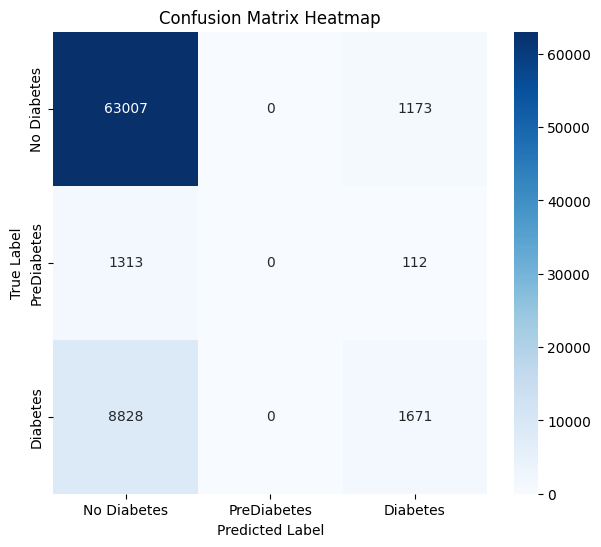

In [35]:
# ==============================
# 10. Confusion Matrix Visualization
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns

classes = ['No Diabetes', 'PreDiabetes', 'Diabetes']

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()